# Severe Tropical Cyclones

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})


```{glue:figure} tracks_fig
:scale: 50%
:align: center
```


```{glue:figure} time_cat_fig
:scale: 40%
:align: center
```

**Figure. Severe Tropical cyclones (TCs) in the vicinity of Palau since 1950.**  Map showing all severe TC tracks in the vicinity of Palau (top) and annual storm count (bottom).  Severe cyclones are those classified as Category 3 or greater on the Saffir Simpson scale (i.e., winds greater than 96kt [110 miles/hour]). The dashed black line represents a trend that is not statistically significant.   

## Setup

First, we need to import all the necessary libraries. Some of them are specifically developed to handle the download and plotting of the data and are hosted at the [indicators set-up repository](https://github.com/lauracagigal/indicators_setup) in GitHub

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
import os
import os.path as op
from pathlib import Path
import xarray as xr
import pandas as pd
from myst_nb import glue 
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../../../../functions")
from tcs import (Extract_Circle, Plot_TCs_HistoricalTracks_Category,
                  plot_bar_probs, plot_tc_categories_trend, plot_bar_probs_ONI, add_oni_cat)
from data_downloaders import download_ibtracs, download_oni_index
from site_common import load_site_config, list_available_sites, site_config_filename


In [3]:
sites_dir = Path("../../../../data/sites")
available_sites = list_available_sites(sites_dir)
print(f"{len(available_sites)} site(s) already configured in {sites_dir}:")
display(available_sites)

site_key = "palau"  # pick a site_key from the table printed above

site_config_path = sites_dir / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get('site_name', 'Site')
site_lon = float(site_cfg.get('site_lon'))
site_lat = float(site_cfg.get('site_lat'))
country = site_cfg.get('country', site_cfg.get('station_country_filter', 'Country'))

lon_lat = [site_lon, site_lat]  # site location: lon, lat
basin = 'WP'
r1 = 5 # Radius of the circular area in degrees

6 site(s) already configured in ../../../../data/sites:


,site_key,site_name,country,ghcn_station_id,ghcn_station_name,vars_interest
0,cook_islands_new_zealand_cwm00091843,cook_islands_new_zealand_CWM00091843,Cook Islands [New Zealand],CWM00091843,RAROTONGA INTL GSN 91843,"[TMIN, TMAX, PRCP]"
1,marshall_islands_rmw00040604,marshall_islands_RMW00040604,Marshall Islands,RMW00040604,MH KWAJALEIN GSN 91366,"[TMIN, TMAX, PRCP]"
2,marshall_islands_rmw00040710,marshall_islands_RMW00040710,Marshall Islands,RMW00040710,MH MAJURO WBAS AP GSN 91376,"[TMIN, TMAX, PRCP]"
3,niue_new_zealand_nem00091824,niue_new_zealand_NEM00091824,Niue [New Zealand],NEM00091824,HANAN AIRPORT GSN 91824,"[TMIN, TMAX, PRCP]"
4,palau,Palau,Palau,None,None,None
5,palau_psw00040309,palau_PSW00040309,Palau,PSW00040309,PW KOROR GSN 91408,"[TMIN, TMAX, PRCP]"


### IBTrACS
IBTrACS (International Best Track Archive for Climate Stewardship) is the most comprehensive global database of tropical cyclones. It compiles data from all major meteorological agencies worldwide, providing track, intensity, and metadata for storms from 1842 to present. It supports research on cyclone trends, risks, and climate variability.

In [4]:
update_data = False
path_data = "../../../../data/tcs"
path_figs = "../../../../matrix_cc/figures"

os.makedirs(path_data, exist_ok=True)

In [5]:
if update_data:
    url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/IBTrACS.ALL.v04r01.nc'
    tcs = download_ibtracs(url, basin = basin)
    tcs.to_netcdf(f"{path_data}/tcs_{basin}.nc")
else:
    tcs = xr.load_dataset(f"{path_data}/tcs_{basin}.nc")

## Analysis

In [6]:
tcs = tcs.isel(storm = np.where(tcs.isel(date_time = 0).time.dt.year >= 1950)[0])    

In [7]:
d_vns = {
    'longitude': 'lon',
    'latitude': 'lat',
    'time': 'time',
    'pressure': 'wmo_pres',
    'wind': 'wmo_wind',
}
tcs_sel, tcs_sel_params = Extract_Circle(tcs, lon_lat[0], lon_lat[1], r1, d_vns, fillwinds=True)

In [8]:
tcm = tcs_sel.max(dim = 'date_time')
tcmin = tcs_sel.min(dim = 'date_time')

The static plot below shows all the severe TCs in the vicinity of Palau colored by its category. <br>
Severe TCs are defined here as those having a category equal or larger than 3

In [9]:
tcs_sel_params['category'] = (('storm'), np.where(np.isnan(tcs_sel_params.category), -1, tcs_sel_params.category))

In [10]:
tcs_sel_params_severe = tcs_sel_params.where(tcs_sel_params.category >=3, drop=True)
tcs_sel_severe = tcs_sel.sel(storm=tcs_sel_params_severe.storm)

## Plotting

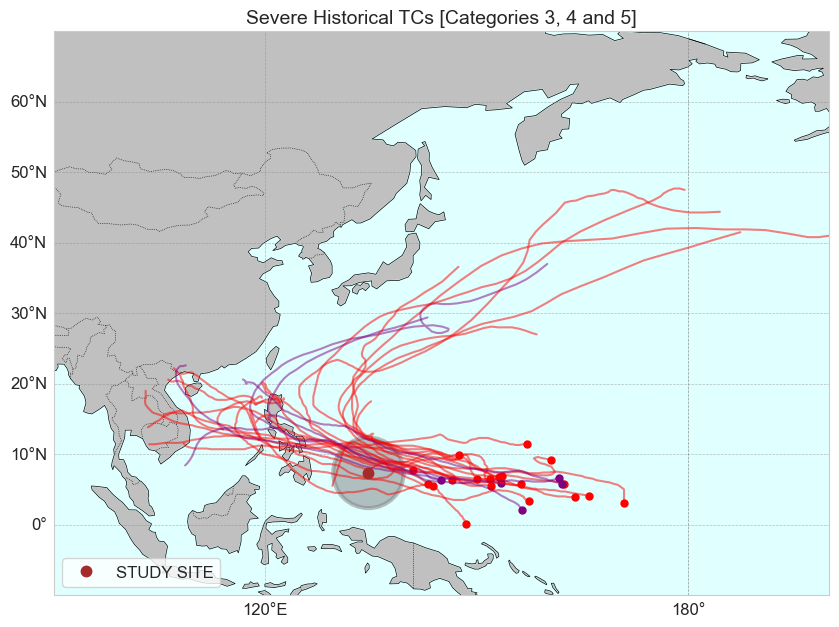

In [11]:
lon1, lon2 = 90, 200
lat1, lat2 = -10, 70

# r1
fig, ax = Plot_TCs_HistoricalTracks_Category(
    tcs_sel_severe, tcs_sel_params_severe.category,
    lon1, lon2, lat1, lat2,
    lon_lat[0], lon_lat[1], r1,
)
ax.set_title('Severe Historical TCs [Categories 3, 4 and 5]', fontsize = 14)
glue("tracks_fig", fig, display=False)

plt.savefig(op.join(path_figs, 'F8_TCs_Historical_Severe.png'), dpi=300, bbox_inches='tight')


The plot below shows the trend of the number of severe TCs per year over time.

(<Figure size 1500x400 with 1 Axes>, <Axes: ylabel='Number of severe TCs'>)

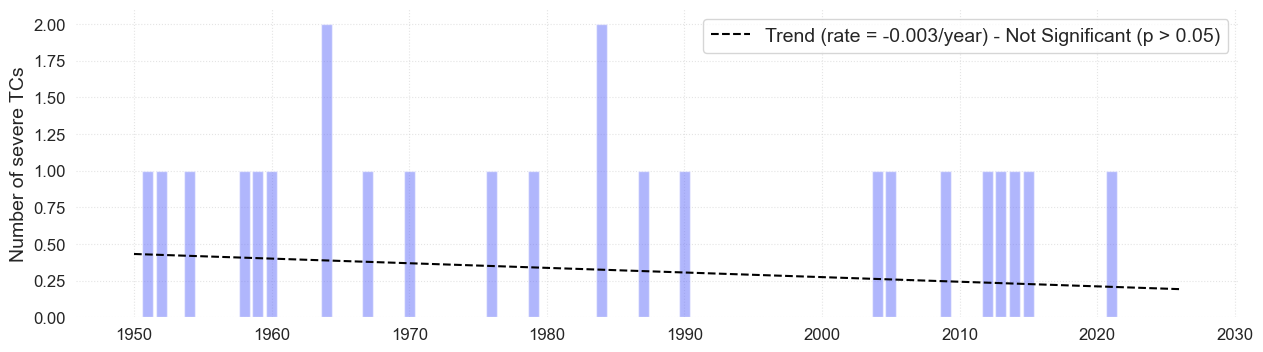

In [12]:
tcs_sel_severe_params = tcs_sel_params.where(tcs_sel_params.category >=3, drop = True)
time = tcs_sel_severe_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
years = np.unique(tcs.isel(date_time = 0).time.dt.year)
cyclone_counts = np.zeros(len(years), dtype=int)
idx = np.searchsorted(years, u)
cyclone_counts[idx] = cu
plot_bar_probs(x = years, y = cyclone_counts, figsize= (15, 4), trendline = True,
               y_label =  'Number of severe TCs')


The following bar plot displays the TC count per year and per category, as well as the trend. <br>
 The grey color represent those TCs in the record where no pressure or wind information is available to determine the corresponding category.

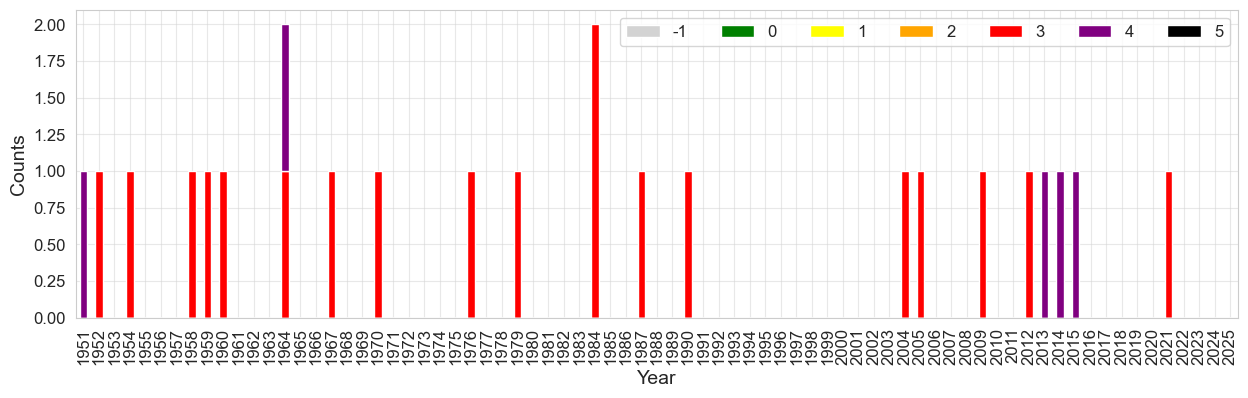

In [13]:

tcs_sel_severe_params['month'] =  tcs_sel_severe_params.dmin_date.dt.month
fig = plot_tc_categories_trend(tcs_sel_severe_params, trendline_plot = False)
plt.savefig(op.join(path_figs, 'F8_TCs_Historical_bars_category_severe.png'), dpi=300, bbox_inches='tight')
glue("time_cat_fig", fig, display=False)
plt.savefig(op.join(path_figs, 'F8_TCs_Historical_Severe_cat_time.png'), dpi=300, bbox_inches='tight')


To showcase the spatial distribution of the TC tracks for the different categories, a map is shown below representing all the TCs in the record for each category.

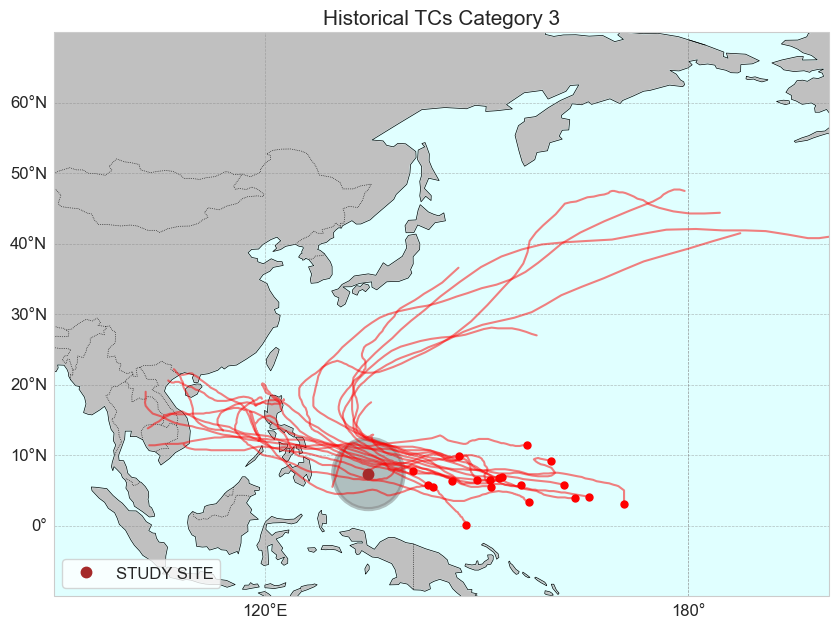

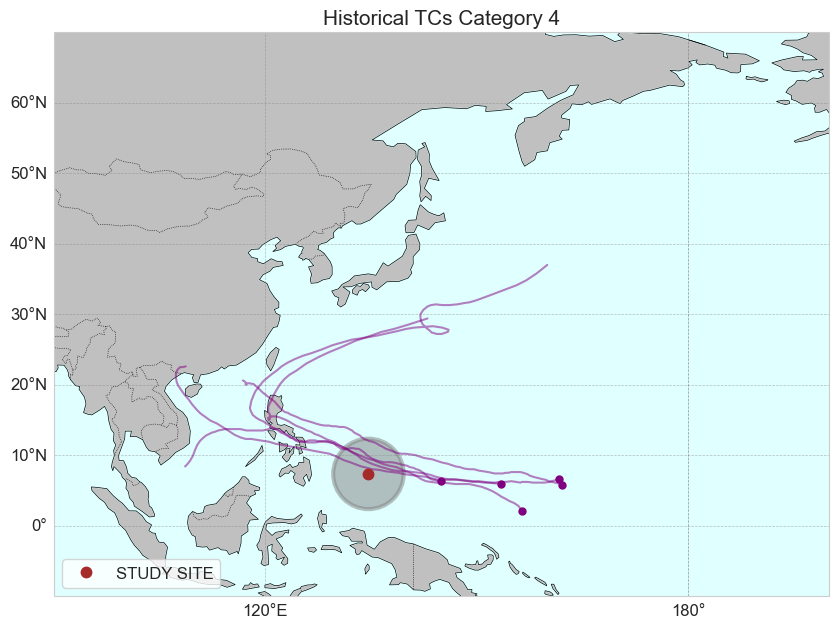

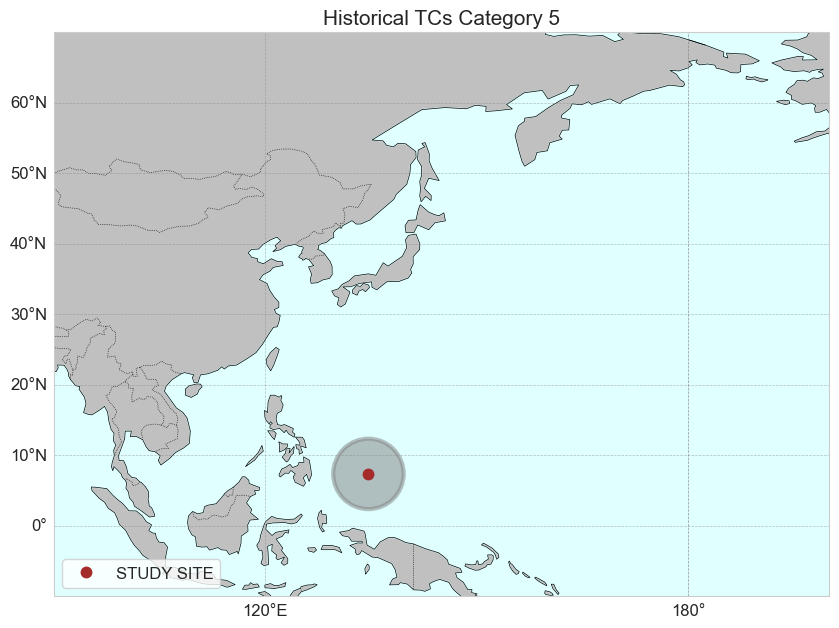

In [14]:

for category in np.arange(3, 6, 1):

    tcs_cat = tcs_sel.where(tcs_sel_params.category == category, drop = True)
    tcs_cat_params = tcs_sel_params.where(tcs_sel_params.category == category, drop = True)

    # r1
    fig, ax = Plot_TCs_HistoricalTracks_Category(
        tcs_cat, tcs_cat_params.category,
        lon1, lon2, lat1, lat2,
        lon_lat[0], lon_lat[1], r1,
    )
    ax.set_title(f'Historical TCs Category {category}', fontsize=15)

### Generate table
Table sumarizing different metrics of the data analyzed in the plots above <br>
Number of TCs for each category

In [15]:
df_tcs = tcs_sel_params.to_dataframe()
df_tcs['year'] = df_tcs.dmin_date.dt.year
df_t = df_tcs.groupby('category').count()[['pressure_min']]
# fig = plot_df_table(df_t, figsize = (300, 220))

mean_tcs_per_year = df_tcs.groupby(df_tcs['dmin_date'].dt.year)['pressure_min'].count()

df_sev = df_tcs.loc[df_tcs['category'] >=3]
mean_tcs_per_year_sev = df_sev.groupby(df_sev['dmin_date'].dt.year)['pressure_min'].count()

print('Mean TCs per year: ', np.nanmean(mean_tcs_per_year))
print('Mean number of severe TCs per year: ', np.round(np.nanmean(mean_tcs_per_year_sev), 2))


Mean TCs per year:  4.48051948051948
Mean number of severe TCs per year:  1.09


## ONI index

The Oceanic Niño Index (ONI) is the standard measure used to monitor El Niño and La Niña events. It is based on sea surface temperature anomalies in the central equatorial Pacific (Niño 3.4 region) averaged over 3-month periods. 

https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php

In [16]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'

In [17]:
if update_data:
    df1 = download_oni_index(p_data)
    df1.to_pickle(op.join(path_data, 'oni_index.pkl'))
else:
    df1 = pd.read_pickle(op.join(path_data, 'oni_index.pkl'))

oni = df1

In [18]:
lims = [-.5, .5]
df1 = add_oni_cat(df1, lims = lims)

In [19]:
import pandas as pd
tcs_g = pd.DataFrame(tcs_sel.isel(date_time = 0).time.values)
tcs_g.index = tcs_g[0]
tcs_g.index = pd.DatetimeIndex(tcs_g.index).to_period('M').to_timestamp() + pd.offsets.MonthBegin(0)
tcs_g['oni_cat'] = oni.oni_cat

In [20]:
tcs_sel_params['oni_cat'] = (('storm'), tcs_g['oni_cat'].values)
tcs_sel['oni_cat'] = (('storm'), tcs_g['oni_cat'].values)

In [21]:
# oni['ONI_cat'] = np.where(oni.ONI < lims[0], -1, np.where(oni.ONI > lims[1], 1, 0))
tcs_sel_params['oni_cat'] = (('storm'), tcs_sel.oni_cat.values)

In [22]:
oni_perc_cat = oni.groupby('oni_cat').size() / oni.shape[0] * 100
oni_perc_cat

oni_cat
-1    31.578947
 0    39.473684
 1    28.947368
dtype: float64

In [23]:
tcs_perc_cat = tcs_sel_params.to_dataframe().groupby('oni_cat').size() * 100 / tcs_sel_params.to_dataframe().shape[0]
tcs_perc_cat

oni_cat
-1.0    29.775281
 0.0    43.258427
 1.0    26.029963
dtype: float64

In [24]:
#Relavice probability
tcs_perc_cat / oni_perc_cat

oni_cat
-1.0    0.942884
 0.0    1.095880
 1.0    0.899217
dtype: float64

In [25]:
time = tcs_sel_params.dmin_date.dt.year.values
u, cu = np.unique(time, return_counts=True)
tc_c = pd.DataFrame(cu, index = u)
time_sev = tcs_sel_params.where(tcs_sel_params.category >= 3, drop = True).dmin_date.dt.year.values
u_sev, cu_sev = np.unique(time_sev, return_counts=True)
tc_c_sev = pd.DataFrame(cu_sev, index = u_sev)

In [26]:
oni_y = oni.groupby(oni.index.year).min()
oni_y['tc_counts'] = tc_c
oni_y['tc_counts_sev'] = tc_c_sev

In [27]:
oni_y['oni_cat'] = oni_y.oni_cat.values

In [28]:
oni_y

,ONI,oni_cat,tc_counts,tc_counts_sev
1951,-0.82,1,10,1.0
1952,-0.08,0,12,1.0
1953,0.40,1,7,NaN
1954,-0.90,-1,8,1.0
1955,-1.67,-1,5,NaN
...,...,...,...,...
2022,-0.97,-1,3,NaN
2023,-0.54,1,3,NaN
2024,-0.42,0,5,NaN
2025,-0.61,0,4,NaN


The following bar plot represents the severe TC counts over time. The color of the bar represents wether it is a El Niño or La Niña year.

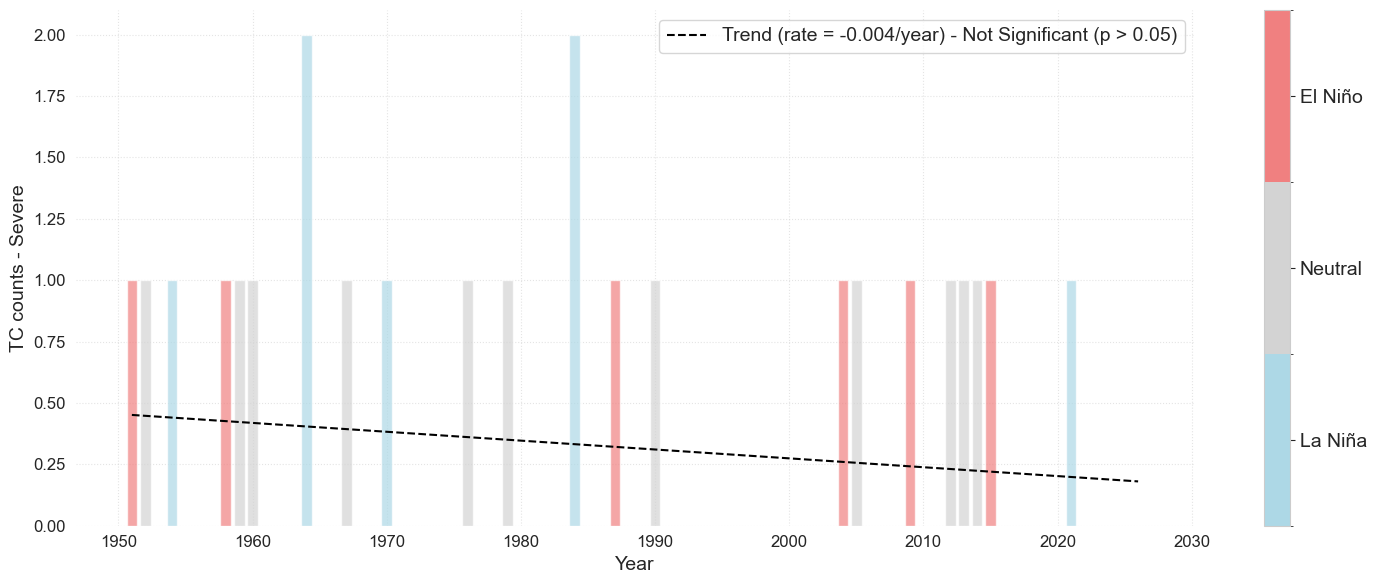

In [29]:
ax = plot_bar_probs_ONI(oni_y.fillna(0), 'tc_counts_sev', y_label= 'TC counts - Severe');
plt.savefig(op.join(path_figs, f'F9_TCs_severe_bars_trend.png'), dpi=300, bbox_inches='tight')



## SEVERE TCs

Category 3, 4 and 5

The following plots represent all the **severe** TCs in the record for the three different phases of the El Niño Southern Oscillation: "El Niño", "Neutral" and "La Niña"

In [30]:
storms_severe_ids = tcs_sel_params.storm.where(tcs_sel_params.category >= 3, drop = True).values

In [31]:
storms_severe = tcs_sel.sel(storm = storms_severe_ids)
storm_severe_params = tcs_sel_params.sel(storm = storms_severe_ids)

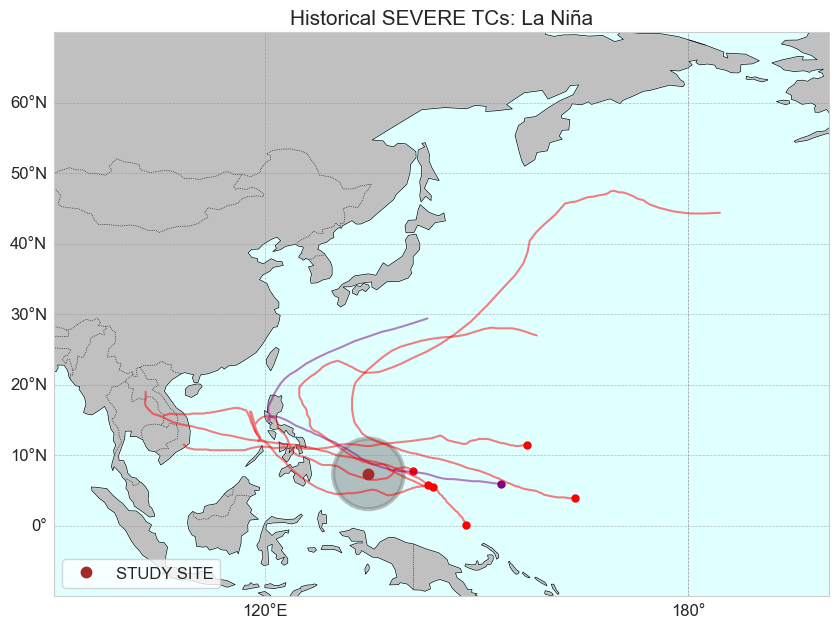

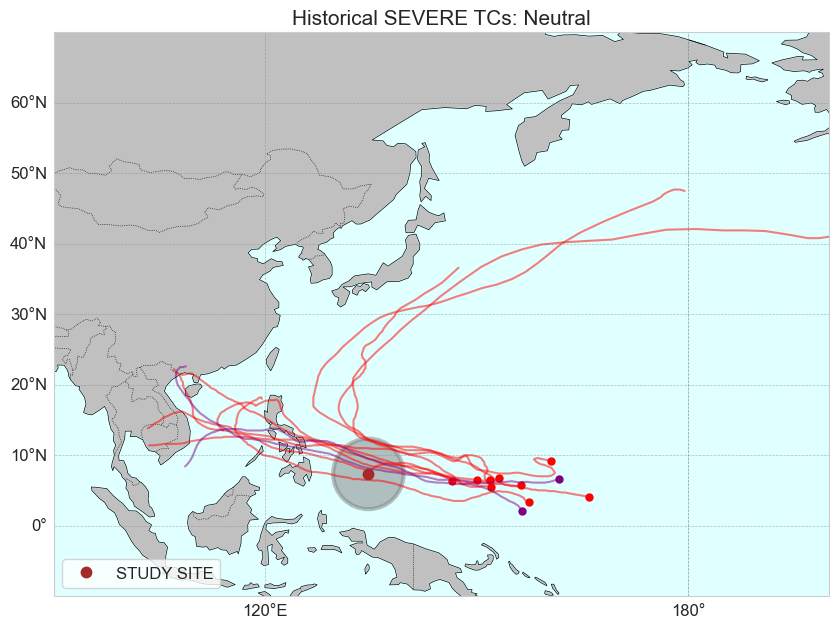

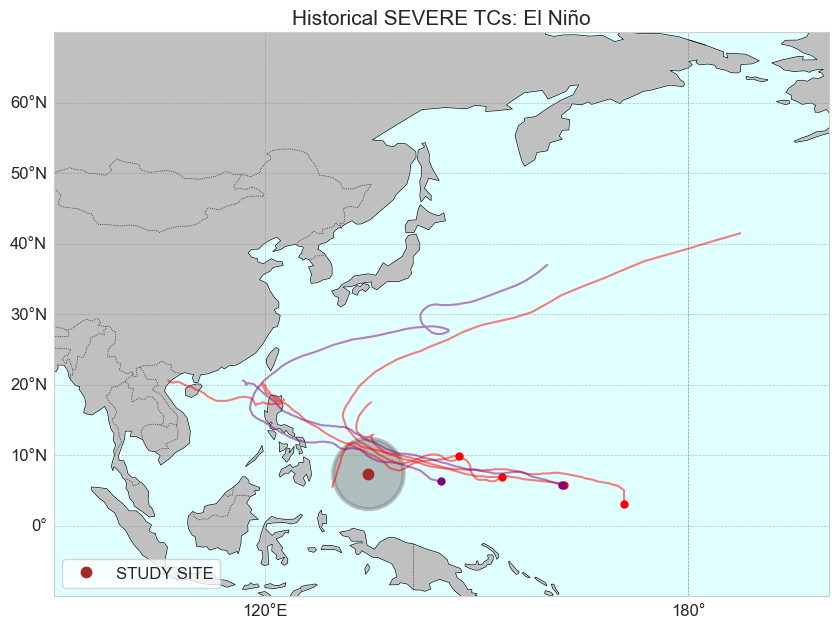

In [32]:
names_cat = ['La Niña', 'Neutral', 'El Niño']
for ic, category in enumerate([-1, 0, 1]):

    tcs_cat = storms_severe.where(storm_severe_params.oni_cat == category, drop = True)
    tcs_cat_params = storm_severe_params.where(storm_severe_params.oni_cat == category, drop = True)

    fig, ax = Plot_TCs_HistoricalTracks_Category(
        tcs_cat, tcs_cat_params.category,
        lon1, lon2, lat1, lat2,
        lon_lat[0], lon_lat[1], r1,
    )
    ax.set_title(f'Historical SEVERE TCs: {names_cat[ic]}', fontsize=15)
    plt.savefig(op.join(path_figs, f'F9_TCs_{names_cat[ic]}_SEVERE.png'), dpi=300, bbox_inches='tight')
    

## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Changes in observing practices and best-track quality can affect historical cyclone counts and intensity estimates.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.